<a href="https://colab.research.google.com/github/emersonaito/kzn-web/blob/main/Te_damos_la_bienvenida_a_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solemne 1 - Taller de Métodos Cuantitativos

**Asignatura:** FMSV316 - Taller de Métodos Cuantitativos

**Caso:** ACEROMEC S.A. – Control de calidad de pasadores de acero

**Alumno:** Emerson Giovanni Araya Sandoval

In [11]:
# Importar librerias
import pandas as pd
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Base de datos cargada
df = pd.read_excel("Solemne1_FMSV316_BaseDatos.xlsx", sheet_name="Datos")

df.head()

,ID_Pieza,Línea_Producción,Turno,Operario_Certificado,Diámetro_mm,Peso_g,Dureza_HRC,Microfracturas,Nivel_Calidad,Resultado_Inspección
0,1001,Línea A,Mañana,No,10.070,44.38,61.10,0,Alto,Aprobado
1,1002,Línea C,Noche,No,10.020,45.32,59.63,0,Alto,Aprobado
2,1003,Línea A,Mañana,Sí,9.983,44.73,54.89,0,Medio,Aprobado
3,1004,Línea B,Noche,Sí,9.784,42.99,59.54,2,Bajo,Rechazado
4,1005,Línea B,Mañana,Sí,9.995,44.93,55.07,2,Bajo,Rechazado


In [13]:
# Información general de la base de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID_Pieza              180 non-null    int64  
 1   Línea_Producción      180 non-null    object 
 2   Turno                 180 non-null    object 
 3   Operario_Certificado  180 non-null    object 
 4   Diámetro_mm           180 non-null    float64
 5   Peso_g                180 non-null    float64
 6   Dureza_HRC            180 non-null    float64
 7   Microfracturas        180 non-null    int64  
 8   Nivel_Calidad         180 non-null    object 
 9   Resultado_Inspección  180 non-null    object 
dtypes: float64(3), int64(2), object(5)
memory usage: 14.2+ KB


In [47]:

#Pregunta 1.1
#Clasificación de las variables de la base de datos
#Creamos una tabla con las variables indicadas en el enunciado y su correspondiente clasificación estadística.

clasificacion = pd.DataFrame({
#Variables a clasificar.
    "Variable": [
        "Línea_Producción",
        "Turno",
        "Operario_Certificado",
        "Diámetro_mm",
        "Peso_g",
        "Dureza_HRC",
        "Microfracturas",
        "Nivel_Calidad"
    ],
#Tipo estadístico de cada variable.
    "Tipo de variable": [
        "Cualitativa nominal",
        "Cualitativa nominal",
        "Cualitativa nominal",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa continua",
        "Cuantitativa discreta",
        "Cualitativa ordinal"
    ]

})
#Mostramos la tabla con la clasificación de las variables.
clasificacion

,Variable,Tipo de variable
0,Línea_Producción,Cualitativa nominal
1,Turno,Cualitativa nominal
2,Operario_Certificado,Cualitativa nominal
3,Diámetro_mm,Cuantitativa continua
4,Peso_g,Cuantitativa continua
5,Dureza_HRC,Cuantitativa continua
6,Microfracturas,Cuantitativa discreta
7,Nivel_Calidad,Cualitativa ordinal


# Sección 1 – Tipos de datos

## Pregunta 1.1

Clasifique las siguientes ocho variables de la base de datos según su tipo:
- Cuantitativa continua
- Cuantitativa discreta
- Cualitativa nominal
- Cualitativa ordinal

### Interpretación

Las variables de la base de datos corresponden tanto a variables cualitativas como cuantitativas. Las variables Línea_Producción, Turno y Operario_Certificado son cualitativas nominales, ya que clasifican las observaciones en categorías sin un orden natural. Nivel_Calidad es una variable cualitativa ordinal porque sus categorías presentan un orden jerárquico (Bajo, Medio y Alto). Por otra parte, Diámetro_mm, Peso_g y Dureza_HRC son variables cuantitativas continuas, debido a que representan mediciones que pueden tomar valores decimales. Finalmente, **Microfracturas** corresponde a una variable cuantitativa discreta, ya que representa el conteo del número de microfracturas detectadas en cada pieza.

## Pregunta 1.2

Justifique:

a) ¿Por qué Diámetro_mm es continua y Microfracturas es discreta, a pesar de que ambas son cuantitativas?

b) ¿Por qué Nivel_Calidad es ordinal y no nominal, a diferencia de Línea_Producción?

In [49]:
#Pregunta 1.2
#Revisión de los valores presentes en las variables
#Mostramos algunos valores del diámetro para verificar
#que corresponde a una variable numérica continua.
print("Primeros valores de Diámetro_mm:")
print(df["Diámetro_mm"].head())
#Mostramos los valores únicos de Microfracturas para comprobar
#que corresponde a una variable cuantitativa discreta.
print("\nValores de Microfracturas:")
print(df["Microfracturas"].unique())
#Mostramos las categorías de Nivel_Calidad para identificar
#el orden de sus categorías.
print("\nCategorías de Nivel_Calidad:")
print(df["Nivel_Calidad"].unique())
#Mostramos las categorías de Línea_Producción para verificar
#que corresponde a una variable cualitativa nominal.

print("\nCategorías de Línea_Producción:")
print(df["Línea_Producción"].unique())

Primeros valores de Diámetro_mm:
0    10.070
1    10.020
2     9.983
3     9.784
4     9.995
Name: Diámetro_mm, dtype: float64

Valores de Microfracturas:
[0 2 1 3]

Categorías de Nivel_Calidad:
['Alto' 'Medio' 'Bajo']

Categorías de Línea_Producción:
['Línea A' 'Línea C' 'Línea B']


### Respuesta

a) Las variables Diámetro_mm y Microfracturas son cuantitativas porque ambas se expresan mediante valores numéricos. Sin embargo, Diámetro_mm es una variable continua, ya que corresponde a una medición y puede tomar cualquier valor dentro de un intervalo, incluyendo valores decimales. En cambio, Microfracturas es una variable discreta porque representa el conteo de microfracturas detectadas en cada pieza, por lo que solo puede tomar valores enteros como 0, 1, 2 o más.

b) La variable Nivel_Calidad es cualitativa ordinal porque sus categorías presentan un orden natural: Bajo, Medio y Alto. Este orden permite establecer que un nivel es superior o inferior a otro. En cambio, Línea_Producción es cualitativa nominal, debido a que las categorías Línea A, Línea B y Línea C solo identifican diferentes líneas de fabricación y no presentan una jerarquía entre ellas.

# Sección 2 – Medidas de localización

## Pregunta 2.1

Calcule la media y la mediana de **Diámetro_mm** considerando las 180 piezas de la muestra. Compare ambos valores con la especificación de diseño de **10,00 mm** e interprete qué indica esta comparación sobre el centrado del proceso de fabricación.

In [18]:
# Pregunta 2.1
# Calculamos la media y la mediana del diámetro

media_diametro = np.mean(df["Diámetro_mm"])
mediana_diametro = np.median(df["Diámetro_mm"])

# Redondeamos a tres decimales, igual que los datos de la base
media_diametro = round(media_diametro, 3)
mediana_diametro = round(mediana_diametro, 3)

print("Media del diámetro:", media_diametro, "mm")
print("Mediana del diámetro:", mediana_diametro, "mm")
print("Valor de diseño:", 10.00, "mm")

Media del diámetro: 9.999 mm
Mediana del diámetro: 10.007 mm
Valor de diseño: 10.0 mm


### Interpretación

La media del diámetro de las 180 piezas es de **9,999 mm**, mientras que la mediana es de 10,007 mm. Ambos valores son muy cercanos a la especificación de diseño de 10,00 mm, por lo que el proceso de fabricación se encuentra, en términos generales, correctamente centrado respecto al valor objetivo.

Además, la diferencia entre la media y la mediana es muy pequeña, lo que indica que no existe un desplazamiento importante del proceso hacia diámetros mayores o menores. En consecuencia, el proceso presenta un buen centrado alrededor de la especificación de diseño, aunque será necesario analizar la variabilidad de cada línea de producción para determinar si todas mantienen este mismo comportamiento.

## Pregunta 2.2

Calcule la moda de Microfracturas y la moda de Nivel_Calidad. Explique, en cada caso, qué información aporta la moda y por qué es una medida aplicable tanto a variables cuantitativas discretas como a variables cualitativas.

In [20]:
#Pregunta 2.2
#Calculamos la moda

moda_microfracturas = df["Microfracturas"].mode()[0]
moda_nivel_calidad = df["Nivel_Calidad"].mode()[0]

print("Moda de Microfracturas:", moda_microfracturas)
print("Moda de Nivel_Calidad:", moda_nivel_calidad)
print("\nFrecuencia de Microfracturas:")
print(df["Microfracturas"].value_counts())

print("\nFrecuencia de Nivel_Calidad:")
print(df["Nivel_Calidad"].value_counts())

Moda de Microfracturas: 0
Moda de Nivel_Calidad: Medio

Frecuencia de Microfracturas:
Microfracturas
0    104
1     50
2     19
3      7
Name: count, dtype: int64

Frecuencia de Nivel_Calidad:
Nivel_Calidad
Medio    84
Alto     54
Bajo     42
Name: count, dtype: int64


### Interpretación

La moda de Microfracturas es 0, lo que indica que el número de microfracturas que aparece con mayor frecuencia en las piezas inspeccionadas es cero. Esto significa que la mayoría de las piezas no presenta este tipo de defecto.

La moda de Nivel_Calidad es Medio, lo que indica que esta es la categoría de calidad más frecuente dentro de la muestra analizada.

En ambos casos, la moda entrega información sobre el valor o categoría que ocurre con mayor frecuencia. Esta medida puede aplicarse a Microfracturas porque es una variable cuantitativa discreta cuyos valores enteros pueden repetirse, y también a **Nivel_Calidad** porque es una variable cualitativa, donde la moda permite identificar la categoría predominante sin necesidad de realizar operaciones matemáticas.

## Pregunta 2.3

La media y la mediana del Diámetro_mm resultan muy cercanas entre sí. ¿Qué le permite concluir esto sobre la forma de la distribución? ¿Qué esperaría observar en la relación entre media y mediana si el proceso presentara una asimetría marcada hacia valores altos?

In [21]:
#Pregunta 2.3
#Mostramos resultados obtenidos anteriormente

print("Media:", media_diametro, "mm")
print("Mediana:", mediana_diametro, "mm")

Media: 9.999 mm
Mediana: 10.007 mm


### Interpretación

La media (9,999 mm) y la mediana (10,007 mm) son muy similares, lo que sugiere que la distribución del diámetro es aproximadamente simétrica y que el proceso está centrado cerca de la especificación de diseño.

Si existiera una asimetría marcada hacia valores altos, la media sería mayor que la mediana, debido a la influencia de los valores elevados sobre el promedio.

# Sección 3 – Medidas de variabilidad

## Pregunta 3.1

Filtre la base de datos por Línea_Producción y, para el Diámetro_mm de la Línea A y de la Línea B por separado, calcule:

- Rango
- Varianza muestral
- Desviación estándar muestral
- Coeficiente de variación# Sección 3 – Medidas de variabilidad

## Pregunta 3.1

Filtre la base de datos por Línea_Producción y, para el Diámetro_mm de la Línea A y de la Línea B por separado, calcule:

- Rango
- Varianza muestral
- Desviación estándar muestral
- Coeficiente de variación

In [38]:
#Pregunta 3.1
#Medidas de variabilidad para el diámetro de las Líneas A y B
#Filtramos la base de datos para trabajar por separado con
#las piezas fabricadas en la Línea A y la Línea B.
linea_A = df[df["Línea_Producción"] == "Línea A"]
linea_B = df[df["Línea_Producción"] == "Línea B"]
#Calculamos las medidas de variabilidad para la Línea A.
#Rango = valor máximo - valor mínimo
rango_A = linea_A["Diámetro_mm"].max() - linea_A["Diámetro_mm"].min()
#Varianza muestral
varianza_A = linea_A["Diámetro_mm"].var()
#Desviación estándar muestral
desviacion_A = linea_A["Diámetro_mm"].std()
#Coeficiente de variación
cv_A = (desviacion_A / linea_A["Diámetro_mm"].mean()) * 100
#Calculamos las medidas de variabilidad para la Línea B.
rango_B = linea_B["Diámetro_mm"].max() - linea_B["Diámetro_mm"].min()
varianza_B = linea_B["Diámetro_mm"].var()
desviacion_B = linea_B["Diámetro_mm"].std()
cv_B = (desviacion_B / linea_B["Diámetro_mm"].mean()) * 100
#Creamos una tabla para comparar los resultados obtenidos
#entre ambas líneas de producción.
resultado = pd.DataFrame({

    "Medida": [
        "Rango",
        "Varianza muestral",
        "Desviación estándar",
        "Coeficiente de variación (%)"
    ],

    "Línea A": [
        round(rango_A, 4),
        round(varianza_A, 6),
        round(desviacion_A, 6),
        round(cv_A, 2)
    ],

    "Línea B": [
        round(rango_B, 4),
        round(varianza_B, 6),
        round(desviacion_B, 6),
        round(cv_B, 2)
    ]

})

#Mostramos la tabla final con los resultados
resultado

,Medida,Línea A,Línea B
0,Rango,1.340000,0.860000
1,Varianza muestral,0.018552,0.024404
2,Desviación estándar,0.136205,0.156218
3,Coeficiente de variación (%),1.360000,1.560000


### Interpretación

La Línea B presenta una mayor variabilidad que la Línea A, ya que posee un mayor valor de varianza, desviación estándar y coeficiente de variación. Además, la Línea A presenta un rango mayor (1,34 mm frente a 0,86 mm), lo que indica que la diferencia entre su valor mínimo y máximo es superior.

En términos generales, la Línea A muestra una menor dispersión en la mayoría de las medidas analizadas, por lo que su proceso de fabricación resulta más consistente que el de la Línea B.

## Pregunta 3.2

Compare los resultados obtenidos para ambas líneas. ¿Cuál de las dos presenta un proceso más homogéneo o controlado en el diámetro fabricado? Fundamente su respuesta utilizando los estadísticos calculados.

In [39]:
#Pregunta 3.2
#Comparación de la variabilidad entre las Líneas A y B
#Mostramos nuevamente la tabla obtenida en la pregunta anterior
#para comparar las medidas de variabilidad de ambas líneas
resultado

,Medida,Línea A,Línea B
0,Rango,1.340000,0.860000
1,Varianza muestral,0.018552,0.024404
2,Desviación estándar,0.136205,0.156218
3,Coeficiente de variación (%),1.360000,1.560000


### Interpretación

La Línea A muestra un proceso más homogéneo que la Línea B, ya que presenta una menor varianza, desviación estándar y coeficiente de variación. Esto significa que los diámetros de las piezas son más consistentes y varían menos respecto de su promedio.

Si bien la Línea A tiene un rango mayor, esta medida solo considera los valores extremos. En este caso, las medidas que consideran todas las observaciones indican que la Línea A mantiene un mejor control sobre el diámetro fabricado.

## Pregunta 3.3

Si la meta de la planta es mantener un coeficiente de variación bajo en el diámetro de todas sus líneas, ¿qué recomendación le haría a la Jefatura de Producción a partir de sus resultados?

In [40]:
#Pregunta 3.3
#Mostramos nuevamente los resultados obtenidos


resultado

,Medida,Línea A,Línea B
0,Rango,1.340000,0.860000
1,Varianza muestral,0.018552,0.024404
2,Desviación estándar,0.136205,0.156218
3,Coeficiente de variación (%),1.360000,1.560000


### Interpretación

Como la Línea B tiene un coeficiente de variación más alto, recomendaría revisar su proceso de fabricación para identificar qué está generando una mayor variabilidad en el diámetro de las piezas.

Una posible medida sería verificar la calibración de las máquinas y reforzar el control del proceso, con el objetivo de reducir la dispersión de los diámetros y obtener una producción más uniforme.

# Sección 4 – Percentiles

## Pregunta 4.1

Utilizando únicamente las piezas de la Línea B, calcule el percentil 10 (P10), el primer cuartil (Q1), la mediana, el tercer cuartil (Q3) y el percentil 90 (P90) de Diámetro_mm.

In [41]:
#Pregunta 4.1
#Cálculo de percentiles para el diámetro de la Línea B
#Seleccionamos solamente la variable Diámetro_mm de la Línea B
diametro_B = linea_B["Diámetro_mm"]
#Calculamos los percentiles solicitados
p10 = np.percentile(diametro_B, 10)
q1 = np.percentile(diametro_B, 25)
mediana_B = np.percentile(diametro_B, 50)
q3 = np.percentile(diametro_B, 75)
p90 = np.percentile(diametro_B, 90)
#Creamos una tabla con los resultados
percentiles_B = pd.DataFrame({
    "Percentil": ["P10", "Q1", "Mediana", "Q3", "P90"],
    "Diámetro Línea B (mm)": [
        round(p10, 3),
        round(q1, 3),
        round(mediana_B, 3),
        round(q3, 3),
        round(p90, 3)
    ]
})

#Mostramos la tabla
percentiles_B

,Percentil,Diámetro Línea B (mm)
0,P10,9.789
1,Q1,9.869
2,Mediana,9.991
3,Q3,10.089
4,P90,10.144


### Interpretación

Los percentiles permiten conocer cómo se distribuyen los diámetros de las piezas de la Línea B. El P10 indica el valor bajo el cual se encuentra el 10% de las piezas, mientras que el P90 representa el valor bajo el cual se encuentra el 90%.
Por su parte, Q1, la mediana y Q3 dividen los datos en cuatro partes y permiten observar la ubicación del 25%, 50% y 75% de las piezas dentro de la distribución.

## Pregunta 4.2

Interprete el valor de P10 obtenido en relación con el límite inferior de tolerancia (9,80 mm). ¿Qué porcentaje de piezas de la Línea B se ubica por debajo de ese límite? ¿Qué implicancia tiene esto para el control de calidad de esa línea?

In [43]:
#Pregunta 4.2
#Mostramos los percentiles calculados para la Línea B


percentiles_B

,Percentil,Diámetro Línea B (mm)
0,P10,9.789
1,Q1,9.869
2,Mediana,9.991
3,Q3,10.089
4,P90,10.144


### Interpretación

El percentil 10 (P10) de la Línea B es 9,789 mm, valor que se encuentra levemente por debajo del límite inferior de tolerancia de 9,80 mm.

Esto indica que aproximadamente el **10% de las piezas** presenta diámetros cercanos o inferiores a ese límite, por lo que existe una parte de la producción que podría no cumplir con la especificación establecida.

A partir de estos resultados, sería recomendable revisar el proceso de fabricación de la Línea B para reducir la variabilidad y disminuir el riesgo de producir piezas fuera de tolerancia.

## Pregunta 4.3

Calcule el rango intercuartílico (RIC) y los límites de Tukey (LI = Q1 − 1.5·RIC; LS = Q3 + 1.5·RIC) para el Diámetro_mm de la Línea B. Identifique cuántas piezas son consideradas valores atípicos y cuáles son sus valores.

In [44]:
#Pregunta 4.3
#Cálculo del RIC y detección de valores atípicos
#Utilizamos los cuartiles obtenidos anteriormente
ric = q3 - q1
#Calculamos los límites de Tukey
limite_inferior = q1 - (1.5 * ric)
limite_superior = q3 + (1.5 * ric)
#Buscamos las piezas que quedan fuera de esos límites
atipicos = diametro_B[(diametro_B < limite_inferior) | (diametro_B > limite_superior)]
#Mostramos los resultados
print("Rango intercuartílico (RIC):", round(ric, 3))
print("Límite inferior:", round(limite_inferior, 3))
print("Límite superior:", round(limite_superior, 3))

print("\nCantidad de valores atípicos:", len(atipicos))

print("\nValores atípicos:")
print(atipicos)

Rango intercuartílico (RIC): 0.22
Límite inferior: 9.54
Límite superior: 10.418

Cantidad de valores atípicos: 1

Valores atípicos:
18    10.58
Name: Diámetro_mm, dtype: float64


### Interpretación

El rango intercuartílico (RIC) obtenido es de 0,220 mm, lo que representa la dispersión del 50% central de los diámetros de la Línea B.

Al aplicar los límites de Tukey (9,540 mm y 10,418 mm), se identificó un valor atípico, correspondiente a un diámetro de 10,580 mm. Esto indica que existe una pieza cuyo diámetro es considerablemente mayor al comportamiento general de la línea, por lo que sería recomendable revisar si corresponde a una variación propia del proceso o a una medición fuera de lo habitual.

## Pregunta 5.1

Construya un histograma del **Diámetro_mm** para las 180 piezas de la muestra. Describa la forma de la distribución observada (simetría, concentración y presencia de colas).

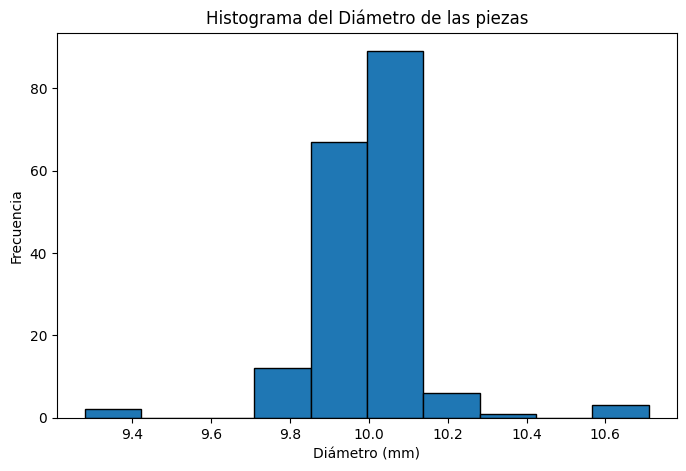

In [45]:
#Pregunta 5.1
#Histograma del diámetro de las 180 piezas
#Creamos el histograma del diámetro de todas las piezas
plt.figure(figsize=(8,5))

plt.hist(df["Diámetro_mm"], bins=10, edgecolor="black")
#Agregamos título y etiquetas
plt.title("Histograma del Diámetro de las piezas")
plt.xlabel("Diámetro (mm)")
plt.ylabel("Frecuencia")
#Mostramos el gráfico
plt.show()

### Interpretación

La mayor parte de los diámetros se concentra cerca de 10,0 mm, por lo que no se observan grandes desviaciones respecto al valor esperado.

La distribución es bastante pareja y solo aparecen algunos valores aislados en los extremos. Destaca un valor alto que ya había sido identificado como un dato atípico en la pregunta anterior.

## Pregunta 5.2

Construya un diagrama de caja (boxplot) del Diámetro_mm, comparando las tres líneas de producción en un mismo gráfico. Interprete las diferencias de centro, dispersión y presencia de valores atípicos entre líneas.

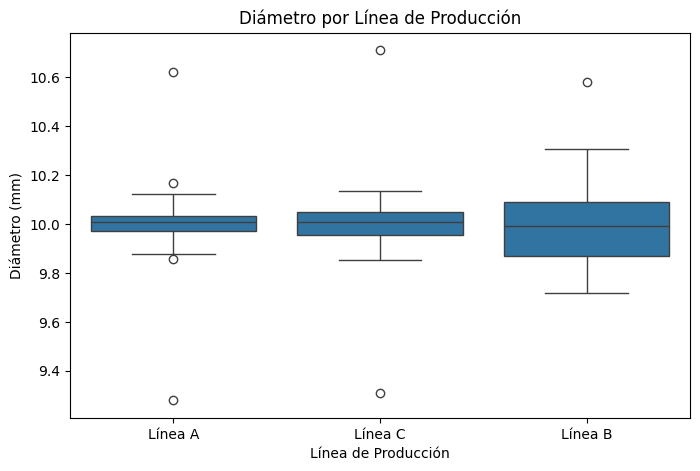

In [46]:
#Pregunta 5.2
#Boxplot del diámetro por línea de producción
#Creamos el gráfico
plt.figure(figsize=(8,5))
#Boxplot por línea de producción
sns.boxplot(x="Línea_Producción",
            y="Diámetro_mm",
            data=df)
#Agregamos título y etiquetas
plt.title("Diámetro por Línea de Producción")
plt.xlabel("Línea de Producción")
plt.ylabel("Diámetro (mm)")
#Mostramos el gráfico
plt.show()

### Interpretación

Al comparar las tres líneas, se observa que todas tienen una mediana cercana a 10,0 mm, por lo que no existen diferencias importantes en el valor central del diámetro.
La Línea B presenta una mayor dispersión que las otras dos, ya que su caja es más amplia y los datos están más distribuidos. En cambio, las líneas A y C muestran un comportamiento más uniforme.
Además, en las tres líneas se observan algunos valores atípicos, lo que indica que existen piezas con diámetros que se alejan del comportamiento habitual del proceso.

Pregunta 5.3
Redacte un diagnóstico integrador de 150 a 200 palabras dirigido a la Jefatura de Producción, en el que indique si existe
evidencia de un problema de calidad, en qué línea se concentra, y qué estadísticos y gráficos respaldan su conclusión.


### Diagnóstico integrador

De acuerdo con los resultados obtenidos, el proceso de fabricación presenta un buen centrado respecto al diámetro objetivo de 10,00 mm, ya que la media y la mediana son muy similares. Además, el histograma muestra que la mayor parte de las piezas se concentra alrededor de ese valor, lo que refleja un comportamiento general adecuado.

No obstante, al analizar las líneas de producción por separado, se observa que la Línea B presenta una mayor variabilidad. Esto se evidencia en su varianza, desviación estándar y coeficiente de variación, los cuales son superiores a los de la Línea A. Asimismo, el percentil 10 se encuentra levemente por debajo del límite inferior de tolerancia y el análisis mediante los límites de Tukey permitió identificar un valor atípico. Estas evidencias también se observan en el boxplot, donde la Línea B presenta una mayor dispersión que las demás.

En función de estos resultados, se recomienda revisar el proceso de fabricación de la Línea B, especialmente aspectos relacionados con el control del proceso y la calibración de los equipos, con el propósito de reducir la variabilidad y mantener una producción más uniforme dentro de las especificaciones establecidas.